In [1]:
# Cell 1: Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.datasets import fashion_mnist
from sklearn.manifold import TSNE

# For consistent plots
# plt.style.use('seaborn')

/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Cell 2: Load and Preprocess Data
# Load the Fashion-MNIST dataset
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Flatten the 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 784) / 255.0  # Normalize pixel values between 0 and 1
x_test = x_test.reshape(-1, 784) / 255.0

# Normalize the data to zero mean and unit variance
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)
x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
# Cell 3: PCA with Different Numbers of Components
components = [100, 50, 10]
reconstructed_images = {}
errors = []

for n_components in components:
    pca = PCA(n_components=n_components)
    pca.fit(x_train)
    x_train_pca = pca.transform(x_test)
    x_reconstructed = pca.inverse_transform(x_train_pca)
    reconstructed_images[n_components] = x_reconstructed
    mse = mean_squared_error(x_test, x_reconstructed)
    errors.append(mse)
    print(f"PCA with {n_components} components - Reconstruction Error: {mse}")


PCA with 100 components - Reconstruction Error: 0.1335294440120205
PCA with 50 components - Reconstruction Error: 0.20552359713420004
PCA with 10 components - Reconstruction Error: 0.3961231521429996


In [4]:
# Cell 3: PCA with Different Numbers of Components
components = [100, 50, 10]
reconstructed_images = {}
errors = []

for n_components in components:
    pca = PCA(n_components=n_components)
    pca.fit(x_train)
    x_train_pca = pca.transform(x_test)
    x_reconstructed = pca.inverse_transform(x_train_pca)
    reconstructed_images[n_components] = x_reconstructed
    mse = mean_squared_error(x_test, x_reconstructed)
    errors.append(mse)
    print(f"PCA with {n_components} components - Reconstruction Error: {mse}")


PCA with 100 components - Reconstruction Error: 0.13346178119878344
PCA with 50 components - Reconstruction Error: 0.2057961457918933
PCA with 10 components - Reconstruction Error: 0.39612296417923626


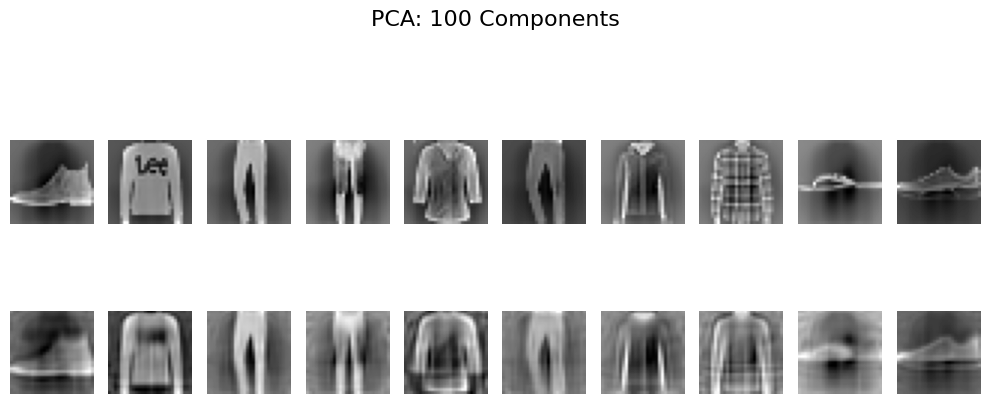

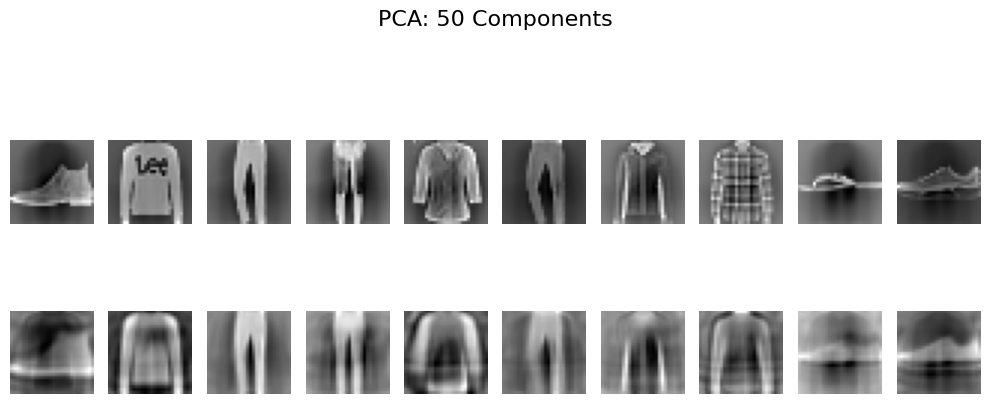

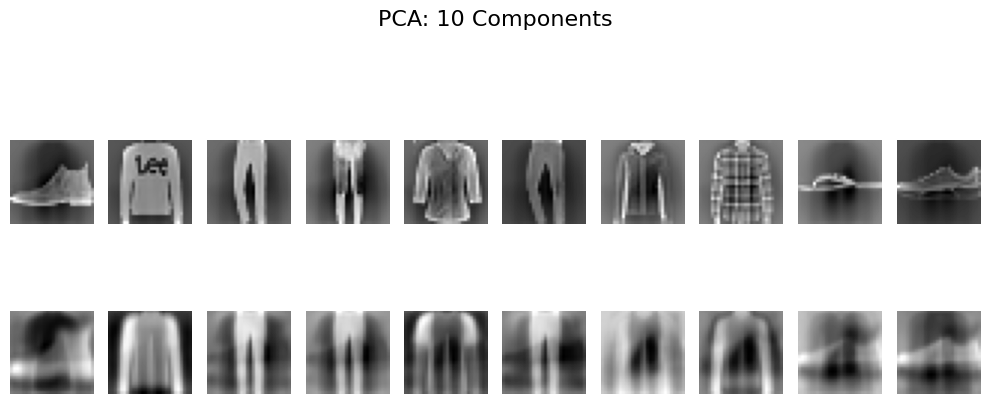

In [5]:
# Cell 4: Visualize Original vs Reconstructed Images (PCA)
def plot_images(original, reconstructed, title):
    plt.figure(figsize=(10, 5))
    for i in range(10):
        # Original images
        plt.subplot(2, 10, i + 1)
        plt.imshow(original[i].reshape(28, 28), cmap='gray')
        plt.axis('off')

        # Reconstructed images
        plt.subplot(2, 10, i + 11)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
        plt.axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

for n_components in components:
    plot_images(x_test, reconstructed_images[n_components], f"PCA: {n_components} Components")


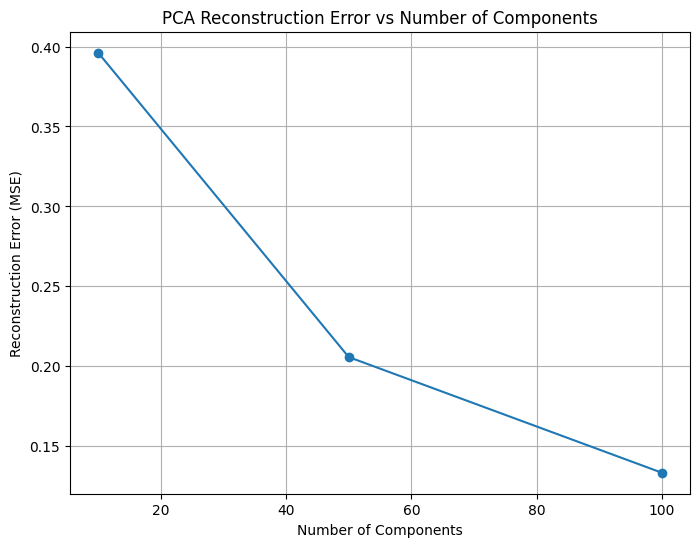

In [6]:
# Cell 5: Analysis of Reconstruction Error (PCA)
plt.figure(figsize=(8, 6))
plt.plot(components, errors, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Reconstruction Error (MSE)')
plt.title('PCA Reconstruction Error vs Number of Components')
plt.grid(True)
plt.show()


In [7]:
# Cell 6: Autoencoder Model Construction
def build_autoencoder(input_dim, encoding_dim):
    # Encoder
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)

    # Decoder
    decoded = Dense(input_dim, activation='sigmoid')(encoded)

    # Autoencoder
    autoencoder = Model(inputs=input_layer, outputs=decoded)
    autoencoder.compile(optimizer='adam', loss='mse')

    return autoencoder

autoencoders = {dim: build_autoencoder(784, dim) for dim in components}


In [8]:
# Cell 7: Train Autoencoders
epochs = 20
batch_size = 256
histories = {}

for encoding_dim, autoencoder in autoencoders.items():
    print(f"Training Autoencoder with {encoding_dim} latent units...")
    history = autoencoder.fit(
        x_train, x_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_test, x_test),
        verbose=1
    )
    histories[encoding_dim] = history.history


Training Autoencoder with 100 latent units...
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.8256 - val_loss: 0.6649
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6445 - val_loss: 0.6403
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6185 - val_loss: 0.6296
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6131 - val_loss: 0.6234
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6025 - val_loss: 0.6194
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6025 - val_loss: 0.6165
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5972 - val_loss: 0.6145
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5943 - val_loss: 0.6129
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5997 - val_loss: 0.6116
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5886 - val_loss: 0.6107
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5882 - val_loss: 0.6100
Epoch 

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step


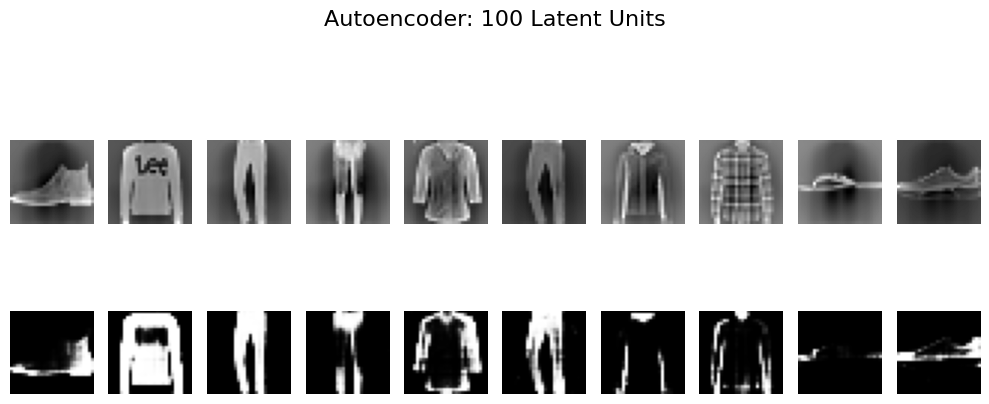

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step


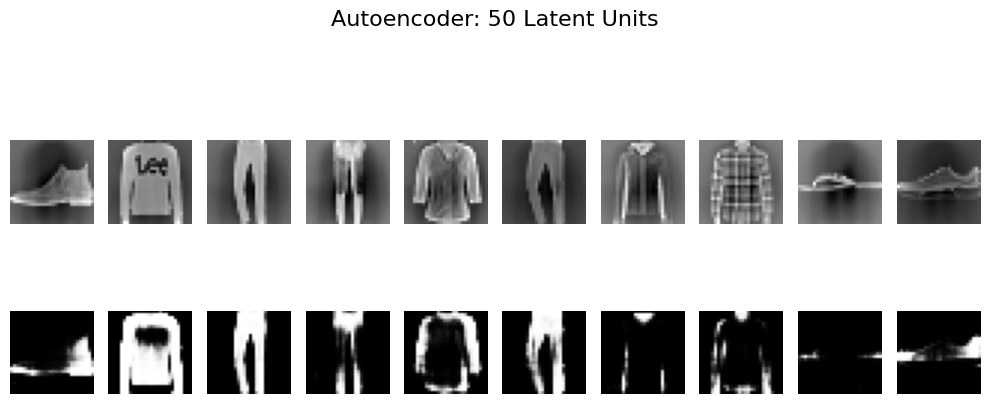

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step


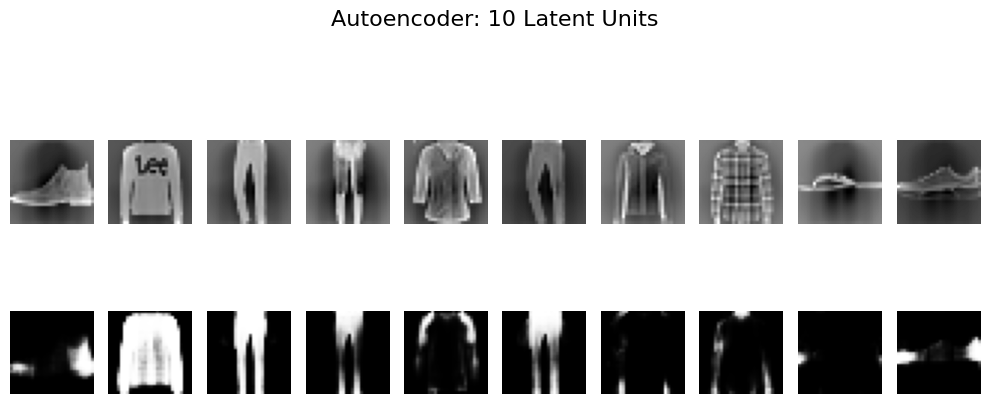

In [9]:
# Cell 8: Visualize Original vs Reconstructed Images (Autoencoder)
autoencoder_reconstructed = {}

for encoding_dim, autoencoder in autoencoders.items():
    reconstructed = autoencoder.predict(x_test)
    autoencoder_reconstructed[encoding_dim] = reconstructed
    plot_images(x_test, reconstructed, f"Autoencoder: {encoding_dim} Latent Units")


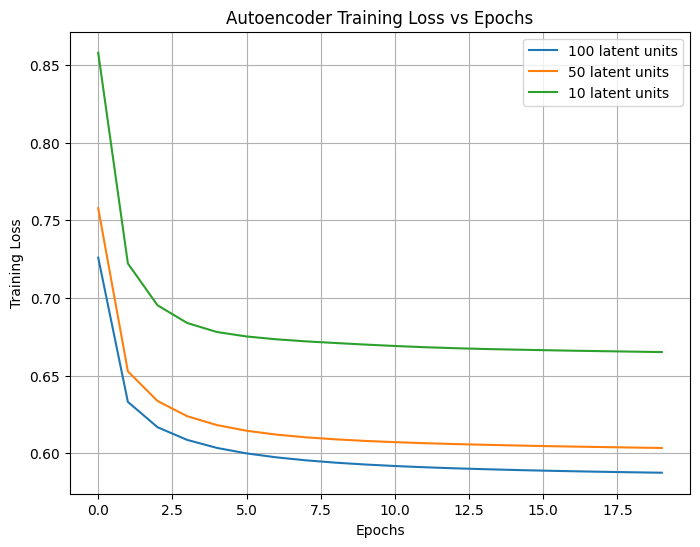

In [ ]:
# Cell 9: Training Loss Visualization
plt.figure(figsize=(8, 6))
for encoding_dim, history in histories.items():
    plt.plot(history['loss'], label=f"{encoding_dim} latent units")

plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Autoencoder Training Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.show()
